In [1]:
import pandas as pd

In [2]:
import mlflow
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("nyc-taxi-experiment")

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1779013425670, experiment_id='1', last_update_time=1779013425670, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}>

In [3]:

train_path = f"data/yellow_tripdata_2023-01.parquet"
val_path = f"data/yellow_tripdata_2023-02.parquet"

In [4]:
def read_dataframe(filepath):
    df = pd.read_parquet(filepath, engine="pyarrow")
    df.tpep_dropoff_datetime = pd.to_datetime(df.tpep_dropoff_datetime)
    df.tpep_pickup_datetime = pd.to_datetime(df.tpep_pickup_datetime)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    df['PU_DO'] = df['PULocationID'] + '_' + df['DOLocationID']
    
    return df

In [6]:
df_train = read_dataframe(train_path)
df_val = read_dataframe(val_path)

In [7]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']
from sklearn.feature_extraction import DictVectorizer
dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [8]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [9]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import root_mean_squared_error, mean_squared_error
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_train)
root_mean_squared_error(y_train, y_pred)


5.133281039752882

In [12]:
import os
os.makedirs("models", exist_ok=True)

In [14]:
import pickle
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

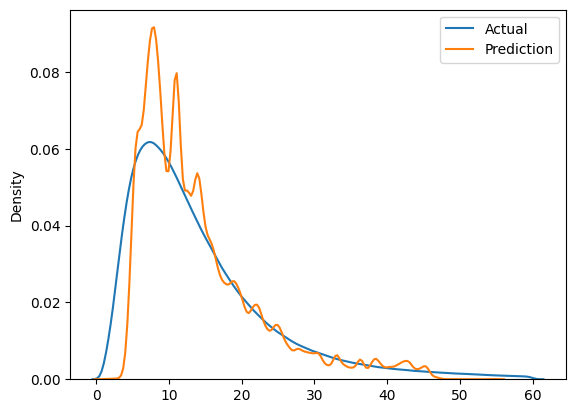

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(y_train, label='Actual')
sns.kdeplot(y_pred, label='Prediction')

plt.legend()
plt.show()

In [17]:
with mlflow.start_run():
    mlflow.set_tag("developer", "linee")
    mlflow.log_param("train-data-path", "./data/yellow_tripdata_2023-01.csv")
    mlflow.log_param("val-data-path", "./data/yellow_tripdata_2023-02.csv")
    
    alpha = 0.01
    mlflow.log_param("alpha", alpha)
    
    ls = Lasso(alpha)
    ls.fit(X_train, y_train)
    y_pred = ls.predict(X_train)
    rmse = root_mean_squared_error(y_train, y_pred)
    mlflow.log_metric("rmse", rmse)
    
    mlflow.log_artifact(local_path="models/lin_reg.bin", artifact_path = "model_pickle")
    

🏃 View run classy-ape-498 at: http://127.0.0.1:5000/#/experiments/1/runs/31ea46e8ce1e4dbfb460445681d8beb0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## Hyperparameter optimizer

In [18]:
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

/home/ubuntu/anaconda3/envs/exp-tracking-env/lib/python3.9/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [19]:
train = xgb.DMatrix(X_train, label=y_train)
val= xgb.DMatrix(X_val, label = y_val)


In [20]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(params = params,
                            dtrain=train,
                            num_boost_round=1000,
                            evals=[(valid, 'validation')],
                            early_stopping_rounds=50)
        
        y_pred = booster.predict(val)
        rmse = root_mean_squared_error(y_val, y_pred)
        
        mlflow.log_metric('rmse', rmse)
        
    return{'loss': rmse, 'status': STATUS_OK}
    

SyntaxError: invalid syntax (359838545.py, line 3)

In [ ]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100,1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed':42
}

best_result = fmin(fn=objective,
                   space=search_space,
                   algo = tpe.suggest,
                   max_evals=50,
                   trials=Trials())

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import LinearSVR

mlflow.autolog()
for model_class in (RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor):
    with mlflow.start_run():
        mlflow.log_param("train-data-path", "./data/green_tripdata_2021-01.csv")
        mlflow.log_param("valid-data-path", "./data/green_tripdata_2021-02.csv")
        mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor")

        mlmodel = model_class()
        mlmodel.fit(X_train, y_train)

        y_pred = mlmodel.predict(X_val)
        rmse = mean_squared_error(y_val, y_pred, squared=False)
        mlflow.log_metric("rmse", rmse)